### Get EF / AI

In [ ]:
# https://www.altmetric.com/journal-selection-dashboard/#

import requests
from bs4 import BeautifulSoup
import time

def scrape_eigenfactor(base_url, start_page, end_page):
	journal_data = {}

	for page in range(start_page, end_page + 1):
		url = f"{base_url}&page={page}"
		print(page)

		response = requests.get(url)
		if response.status_code != 200:
			print(f"Failed to fetch page {page}: {response.status_code}")
			continue

		soup = BeautifulSoup(response.content, 'html.parser')

		results = soup.find_all('div', class_='results')
		for result in results:
			try:
				rank_text = result.find('div', class_='rank').text.strip()
				if not rank_text.isdigit():
					continue

				journal_name_element = result.find('div', class_='journal')
				if journal_name_element:
					journal_name = journal_name_element.contents[0].strip()
				else:
					continue

				ef_text = result.find('div', class_='EF').text.strip()
				ef = float(ef_text) if '<' not in ef_text else float(ef_text.replace('<', '')) / 2.0

				ef_percentile = int(result.find('div', class_='pholder1').find('div', class_='pnum1').text.strip())
				ai_percentile = int(result.find('div', class_='pholder2').find('div', class_='pnum2').text.strip())

				ai_elements = result.find_all('div', class_='AI')
				ai_text = ai_elements[0].text.strip()
				ai = float(ai_text) if '<' not in ai_text else float(ai_text.replace('<', '')) / 2.0
				efn_text = ai_elements[1].text.strip()
				efn = float(efn_text) if '<' not in efn_text else float(efn_text.replace('<', '')) / 2.0

				href_element = result.find_previous('h3').find('a')
				href = href_element['href'] if href_element else ''

				if href != '':
					issn = href[5:].replace('-', '')

				journal_data[issn] = (issn, journal_name, ef, ef_percentile, ai, ai_percentile, efn)
			except Exception as e:
				print(f"Error parsing journal data: {e}")
				continue

		time.sleep(1)

	return journal_data

base_url = "http://www.eigenfactor.org/projects/journalRank/rankings.php?bsearch=2015&searchby=year&orderby=efn"
start_page = 1
end_page = 229

data = scrape_eigenfactor(base_url, start_page, end_page)

for journal, metrics in list(data.items())[:10]:
	print(f"{journal}: {metrics}")

In [ ]:
import json

with open('eigenfactor.json', 'w') as f:
	json.dump(list(data.values()), f)

### Home pages

In [ ]:
import time, json, random
import requests
from bs4 import BeautifulSoup

def scrape_homepage(id):

	url = f'https://www.scimagojr.com/journalsearch.php?q={id}&tip=sid&clean=0'

	headers = {
		"User-Agent": (
			"Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
			"AppleWebKit/537.36 (KHTML, like Gecko) "
			"Chrome/58.0.3029.110 Safari/537.36"
		)
	}

	response = requests.get(url, headers=headers)

	if response.status_code != 200:
		print(f"Failed to fetch {id}: {response.status_code}")
		return None

	soup = BeautifulSoup(response.content, 'html.parser')
	link = soup.find('a', string='Homepage')

	if link is not None:
		homepage = link.get('href')
		return homepage

	return None

with open('./data/ids.json', 'r', encoding='utf-8') as file:
	journals = json.load(file)

homepages = {}
founds = 0
not_founds = 0

for journal in journals:

	homepage = scrape_homepage(journal)

	if homepage is not None and homepage != '':
		homepages[journal] = homepage
		founds += 1
	else:
		not_founds += 1

	print(f'Found: {founds:,}, not found: {not_founds:,}, total: {founds + not_founds:,} / {len(journals):,}', end='\r')

	time.sleep(1)

with open('./data/raw/homepages.json', 'w', encoding='utf-8') as file:
	json.dump(homepages, file, ensure_ascii=False)

In [ ]:
import json
import matplotlib.pyplot as plt

with open('./data/raw_data.json', 'r', encoding='utf-8') as file:
	journals = json.load(file)

selfs = []

for journal in journals:
	if journal['metrics']['self'] is not None:
		selfs.append(journal['metrics']['self'])

print(len([s for s in selfs if s > 0.0]) / len(selfs))
print(len([s for s in selfs if s > 10]) / len(selfs))

_ = plt.hist([s for s in selfs if s > 0.0], bins=1000)

In [1]:
import json
from tabulate import tabulate

def custom_round(value):
	if value == 0.0:
		return 0.0

	r = 1

	while round(value, r) == 0.0:
		r += 1

	return round(value, r)

def color_value(val, color_val):
	if color_val <= 50:
		# Interpolate from red (255,0,0) to yellow (255,255,0)
		ratio = color_val / 50.0  # 0 -> 0, 50 -> 1
		r = 255
		g = int(255 * ratio)
		b = 0
	else:
		# Interpolate from yellow (255,255,0) to green (0,255,0)
		ratio = (color_val - 50) / 50.0  # 50 -> 0, 100 -> 1
		r = int(255 * (1 - ratio))
		g = 255
		b = 0
	# Use ANSI escape sequence for 24-bit color
	return f"\033[38;2;{r};{g};{b}m{val}\033[0m"

with open('./data/journals/data.json', 'r', encoding='utf-8') as file:
	journals = json.load(file)

#journals.sort(key=lambda x: x['ranks']['scope']['rank'] / x['ranks']['scope']['size'] if x['ranks']['scope']['rank'] is not None else 2)
table = []
i = 0

for journal in journals:
	if len(set(['Social Work', 'Developmental and Educational Psychology', 'Psychiatry and Mental Health']).intersection(set(journal['scopes']))) == 0:
		continue

	d = {"Title": journal['title'][:60]}
	d['rank'] = i + 1

	if journal['scores']['oa'] is not None:
		for metric in journal['scores']:
			score = max(1, min(99, round(journal['scores'][metric] * 100))) if journal['scores'][metric] is not None else None
			value = custom_round(journal['metrics'][metric]) if metric != 'oa' and journal['metrics'][metric] is not None else (None if metric != 'oa' else score)

			d[metric] = color_value(value, score) if score is not None else None

	d['scopes'] = ' | '.join(journal['scopes'])
	d['link'] = journal['link']
	table.append(d)
	i += 1

print(tabulate(table[:5000], headers='keys', colalign=['left'] + ['center'] * 11 + ['left'], tablefmt='grid'))

+--------------------------------------------------------------+--------+------+-----+------+------+-------+--------+-------+------+--------+-------+-------+-------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------+
| Title                                                        |  rank  |  oa  |  h  |  if  |  cs  |  sjr  |  snip  |  ef   |  ai  |  self  |  rti  | top   |   alt | scopes                                                                                                                                                                                                                                    

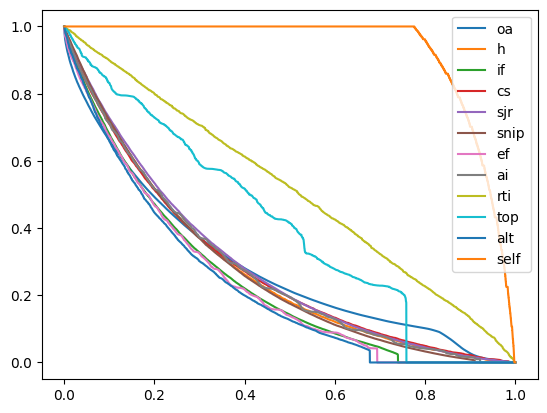

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

METRICS = ['oa', 'h', 'if', 'cs', 'sjr', 'snip', 'ef', 'ai', 'rti', 'top', 'alt', 'self']

with open('./data/journals/data.json', 'r', encoding='utf-8') as file:
	data = json.load(file)

metrics = {metric: [] for metric in METRICS}

for metric in METRICS:
	for journal in data:
		if journal['scores'][metric] is not None:
			metrics[metric].append(journal['scores'][metric])

	min_value = min(metrics[metric])
	max_value = max(metrics[metric])
	metrics[metric] = sorted([(value - min_value) / (max_value - min_value) for value in metrics[metric]], reverse=True)
	#metrics[metric].sort(reverse=True)

for metric in METRICS:
	x_values = np.arange(len(metrics[metric])) / (len(metrics[metric]) - 1)
	y_values = metrics[metric]
	plt.plot(x_values, y_values, label=metric)

plt.legend()
plt.show()

In [8]:
x = 2025
print(0.8 * (max(x, 1900) - 1900))

100.0


In [8]:
import requests
import json

# Define the API endpoint URL
url = f"http://api.semanticscholar.org/graph/v1/paper/search"

# Define the query parameters
query_params = {
	"query": "Evaluation of a brief intervention for educating school children in awareness of physical and sexual abuse",
	"fields": "paperId,title,year,authors.name,externalIds,citationCount,journal,publicationVenue",
	"limit": 2
}

# Send the API request
response = requests.get(url, params=query_params)

# Check response status
if response.status_code == 200:
	response_data = response.json()
	# Process and print the response data as needed
	print(json.dumps(response_data, indent=4))
else:
	print(f"Request failed with status code {response.status_code}: {response.text}")

Request failed with status code 429: {"message": "Too Many Requests. Please wait and try again or apply for a key for higher rate limits. https://www.semanticscholar.org/product/api#api-key-form", "code": "429"}


In [ ]:
from bs4 import BeautifulSoup

html = "<p>Ceci st & du <i>texte</i> avec &amp; des balises.</p>"
text = BeautifulSoup(html, "html.parser").get_text()
print(text)

Ceci st & du texte avec & des balises.


In [ ]:
import json

nb = 0
total = 0
data_path = './test_data.jsonl'

with open(data_path, 'r', encoding='utf-8') as data_file:
	for line in data_file:
		line = line.strip()
		if not line:
			continue

		obj = json.loads(line)

		if obj['summary_stats']['h_index'] > 100:
			if obj['homepage_url'] is None or obj['homepage_url'].strip() == '':
				nb += 1
			total += 1

print(nb / total)
print(total)

0.08914244963451595
5609


In [4]:
import json

nbs = {
	'h': 0,
	'if': 0,
	'cs': 0,
	'sjr': 0,
	'snip': 0,
	'ef': 0,
	'ai': 0,
	'self': 0,
	'rti': 0,
	'top': 0,
	'alt': 0,
	'total': 0,
}

with open('./raw_data.json', 'r', encoding='utf-8') as file:
	data = json.load(file)

for journal in data['journals']:
	for metric in nbs:
		if journal.get('metrics', {}).get(metric) is not None:
			nbs[metric] += 1
	nbs['total'] += 1

print(nbs)

{'h': 38323, 'if': 38323, 'cs': 29413, 'sjr': 37721, 'snip': 35150, 'ef': 11322, 'ai': 11322, 'self': 34447, 'rti': 3198, 'top': 3003, 'alt': 6997, 'total': 46263}
